# Mouse-brain Perturb-seq with causarray 0.1.1: L4-5 IT Glut

This notebook runs causarray on one cell type of the mouse-brain CRISPR screen,
L4-5 IT CTX Glut (58 perturbations, 15,135 non-targeting control cells), from
counts to biological readouts. Every step is a function in `pipeline.py`, and
section 7 runs the same steps for every cell type.

**What we learn from this cell type**

* **56 of 58 perturbations change expression**, with 9,981 hits in total. How many hits a perturbation gets does not track how many cells it has (Spearman 0.02), so the counts reflect how strongly each perturbation acts.
* **Three perturbations dominate: Prpf6 (1,887 hits), Ppp2r1a (1,486) and Tpr (1,457).** Prpf6 and Tpr up-regulate genes of their own machinery (Prpf6, a spliceosome component: mRNA splicing; Tpr, a nuclear-pore protein: transcription and RNA metabolism), and all three down-regulate neuronal genes; Ppp2r1a's up-regulated genes have no clear theme.
* **The proteasome subunits Pomp, Psmc1 and Psmc5 give the most similar responses** (correlation of effects 0.35–0.49), as expected for three parts of one complex.
* **A few genes respond to many perturbations**: activity-regulated Bdnf and Adcyap1 go up in most of the 9–10 perturbations that hit them, while Atp1a1, Scube1 and Ahi1 go down, suggesting a shared response of these neurons to disruption.
* **causarray agrees with Wilcoxon and adds power.** It recovers 86% of the Wilcoxon hits, all in the same direction, and when both methods list the same number of genes they share 68% of them. In both methods the direction of the hits follows expression level: mostly up in weakly expressed genes, mostly down in highly expressed ones. DESeq2 and causarray's count model without the latent factors also find about three quarters of their hits up-regulated, so that majority comes from testing counts, not from causarray's adjustment.
* **Fake perturbations give almost no hits.** On 30 fake perturbations made from control cells, causarray's statistics are close to N(0, 1) (SD 1.03), with 14 hits in total against about 170 per real perturbation.

Words used below:

* **arm**: one group of cells. Each test compares two arms, the controls and
  the cells carrying one perturbation (Tpr, Prpf6, ...).
* **hit** (discovery): a gene–perturbation pair with BH-adjusted p < 0.05; BH is
  applied within each perturbation.
* **tau**: causarray's log fold change (natural log) of a gene's expression,
  perturbed versus control, after adjusting for the latent factors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import causarray
import pipeline as pl
from causarray import estimate_propensity_scores, summarize_propensity_scores, plot_propensity_scores

print('causarray', causarray.__version__)
TAG = 'L45Glut'            # results go to results/L45Glut/
MIN_COUNTS = 20            # UMI counts expected in the smaller arm for a gene to be tested (section 1)
VARIANT = ''               # subfolder of results/L45Glut/ for a run with another min_counts ('' = main run)
RUN_DIR = f'results/{TAG}/{VARIANT}'.rstrip('/')   # this run's causarray results
pl.MIN_COUNTS = MIN_COUNTS
Q = pl.Q                    # FDR level, 0.05
BLUE, ORANGE, PURPLE, GREY = '#2a78d6', '#eb6834', '#8e44ad', '#c8c7c2'
RED, AMBER = '#d62728', '#f2a93b'   # Wilcoxon scatters: hits of both methods, causarray only

causarray 0.1.1


## 1. The pipeline for one cell type

Each step caches its output under `results/L45Glut/` and is skipped when the
cache exists, so the cells below only load results; with no cache the same
calls compute everything.

| step | function | output |
|---|---|---|
| select the cell type | `pl.subset_cell_type(src, '005 L4-5 IT CTX Glut', 'L45Glut')` | `data/L45Glut.h5ad` |
| counts and designs | `pl.load_inputs(tag)` | genes seen in ≥ 50 cells |
| latent factors | `pl.fit_factors(tag, ...)` | `gcate.pkl`, rank r = 8 |
| effects | `pl.run_lfc(tag, ...)` | `lfc.csv` (all controls + 10 perturbations per batch) |
| calibration check | `pl.run_null(tag, ..., seed)` | `null/seed*.csv` |
| Wilcoxon reference | `pl.run_wilcoxon(tag)` | `wilcoxon.h5ad` (crispyx) |

Three settings are fixed for all cell types:

* **rank r = 8** latent factors, chosen by JIC on this cell type and reused to save time;
* **`min_counts = 20`**: the minimum number of UMI counts of a gene expected in
  the smaller arm (the perturbed cells). A gene is tested for a perturbation only
  if its higher arm mean (counts per cell, in the controls or in the perturbed
  cells) times the number of cells in the smaller arm is at least 20. It counts
  UMIs, not cells: for an arm of 100 cells a gene needs 0.2 counts per cell,
  and for the 68–227-cell arms here 0.09–0.29. The package default is 5;
  section 4 shows why we raise it;
* **propensity check**: before each `LFC` call, `pl._propensity` flags any arm
  whose propensity weights concentrate and adjusts that arm only (section 2).

In [2]:
Y, A, X, X_A = pl.load_inputs(TAG)
res_2 = pl.fit_factors(TAG, Y, X, A)
df = pl.run_lfc(TAG, Y, A, X, X_A, res_2, variant=VARIANT)

n_pert = A.sum(0)
print(f'{Y.shape[0]:,} cells x {Y.shape[1]:,} genes; {A.shape[1]} perturbations; '
      f'{int((A.sum(1) == 0).sum()):,} controls')
print(f'cells per perturbation: min {n_pert.min():.0f}, median {n_pert.median():.0f}, max {n_pert.max():.0f}')

22,396 cells x 14,227 genes; 58 perturbations; 15,135 controls
cells per perturbation: min 68, median 122, max 227


## 2. Check the propensity model before reading any effect

causarray reweights cells by the propensity score, the estimated probability
that a cell carries a given perturbation, from its library size and latent
factors. If these covariates nearly separate an arm from the controls, a few
cells get huge weights and dominate that arm's estimates. Three numbers per
perturbation catch this:

* **AUC**: how well the scores separate the two arms (0.5: not at all; above
  about 0.9 is a warning);
* **overlap**: the area the two score histograms share (1: identical; below about
  0.3 is a warning);
* **treated ESS fraction**: how many perturbed cells effectively remain after
  weighting (near 1 is good; below 0.5 means a few cells dominate).

**Library size** (total counts per cell) reflects sequencing depth and capture
efficiency, and causarray adjusts for it in both parts of the estimator: every
gene's outcome model includes each cell's size factor as an offset, and the
propensity model includes log library size as a covariate. Only the second
adjustment can break down: if a covariate nearly separates an arm from the
controls, weighting on it rests that arm's estimates on a few cells.
`pl._propensity` checks each arm and, for a flagged arm only, drops from its
propensity model the covariate most imbalanced against the controls (library
size or a latent factor) until support recovers. The outcome model still
adjusts that arm for library size, and the other arms are untouched.

The scores themselves are small, about 0.01, because controls outnumber the
perturbed cells about 100 to 1. That is expected; a rule like "scores must lie
in [0.05, 0.95]" is meant for balanced designs.

median propensity score of perturbed cells: 0.009
all 58 perturbations: AUC <= 0.74, overlap >= 0.56, treated ESS fraction >= 0.36
perturbations flagged by the automatic check: 1 of 58


,n_treated,auc,overlap_ratio,ess_treated_fraction
treatment,,,,
Tpr,91,0.736,0.560,0.363
Pomp,68,0.672,0.679,0.771
Srsf1,188,0.679,0.699,0.874
Prpf6,78,0.674,0.701,0.748
Sin3a,109,0.667,0.729,0.753


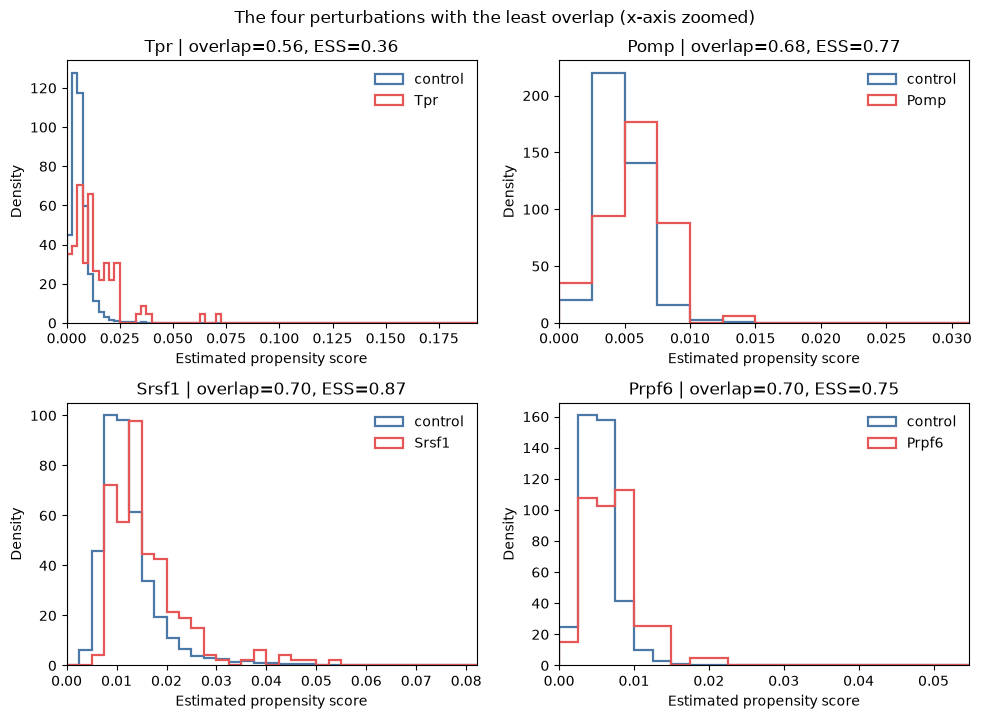

In [3]:
W_A = np.c_[X_A, res_2['U']]
pi = estimate_propensity_scores(A, W_A, K=1, C=1.0, class_weight=None, clip=None, random_state=0)
PS_BINS = 400                # scores sit in [0, 0.1]; 40 default bins would lump them together
ps = summarize_propensity_scores(A, pi, clip_bounds=None, bins=PS_BINS).set_index('treatment')
_, flagged = pl._propensity(A, W_A)

print(f"median propensity score of perturbed cells: {np.median(pi[A.to_numpy() == 1]):.3f}")
print(f"all {len(ps)} perturbations: AUC <= {ps['auc'].max():.2f}, "
      f"overlap >= {ps['overlap_ratio'].min():.2f}, treated ESS fraction >= {ps['ess_treated_fraction'].min():.2f}")
print(f'perturbations flagged by the automatic check: {len(flagged)} of {A.shape[1]}')
display(ps.nsmallest(5, 'overlap_ratio')[['n_treated', 'auc', 'overlap_ratio', 'ess_treated_fraction']].round(3))

show = ps.nsmallest(4, 'overlap_ratio').index.tolist()
fig, axes, _ = plot_propensity_scores(A, pi, treatments=show, clip_bounds=None, bins=PS_BINS,
                                      overlap_bounds=(0, 1))
A_np, ctrl = A.to_numpy(dtype=float), A.to_numpy().sum(1) == 0
for ax, t in zip(np.asarray(axes).ravel(), show):
    j = A.columns.get_loc(t)
    ax.set_xlim(0, 1.05 * pi[ctrl | (A_np[:, j] == 1), j].max())
fig.suptitle('The four perturbations with the least overlap (x-axis zoomed)', y=1.02)
plt.show()

The fit above uses all 58 perturbations at once, as an overview. `LFC` itself
fits the propensity model inside each batch (all controls plus 10
perturbations), and the pipeline runs its check there. The arms it adjusted are
written next to the batch results:

In [4]:
from pathlib import Path
reports = sorted((Path(RUN_DIR) / 'lfc_batches').glob('batch_*_propensity.csv'))
adjusted = pd.concat([pd.read_csv(f) for f in reports], ignore_index=True) if reports else pd.DataFrame()
print(f'arms adjusted inside their LFC batch: {len(adjusted)} of {A.shape[1]}')
if len(adjusted):
    display(adjusted.set_index('treatment')[
        ['dropped', 'auc_all', 'auc_chosen', 'ess_treated_fraction_all', 'ess_treated_fraction_chosen']].round(3))

arms adjusted inside their LFC batch: 1 of 58


,dropped,auc_all,auc_chosen,ess_treated_fraction_all,ess_treated_fraction_chosen
treatment,,,,,
Tpr,log_library_size,0.736,0.579,0.363,0.998


**Conclusion.** The scores are small (median 0.009 for perturbed cells), as expected with about one perturbed cell per 100 controls, and no perturbation is separated from the controls: AUC is at most 0.74 and overlap at least 0.56. One perturbation fails the weighting check: **Tpr**, whose treated ESS fraction is 0.36, so its weights rest on about a third of its cells. Tpr cells have the largest libraries of all arms (18% above the controls, where the median arm is at 98%), and library size is the covariate most imbalanced between Tpr and the controls. For Tpr alone the check drops it from the propensity model, and the ESS fraction returns to 1.0; Tpr's outcome model still adjusts for library size through the size factors. The other 57 perturbations keep library size and every factor in both models.

## 3. Estimate the effects

`pl.run_lfc` calls `LFC` on all controls plus 10 perturbations at a time and
stacks the batches into one table, one row per gene and perturbation. The
columns used most are `tau` (log fold change), `padj` (BH-adjusted p-value),
`count_treated` (total counts of the gene in the perturbed arm) and
`mean_control` (mean counts per control cell).

,L45Glut
gene x perturbation pairs tested,565064
hits,9981
perturbations with >= 1 hit,56 / 58
hits that are down-regulated,24%
hits with zero counts in the perturbed arm,0
median |tau| of hits,0.36


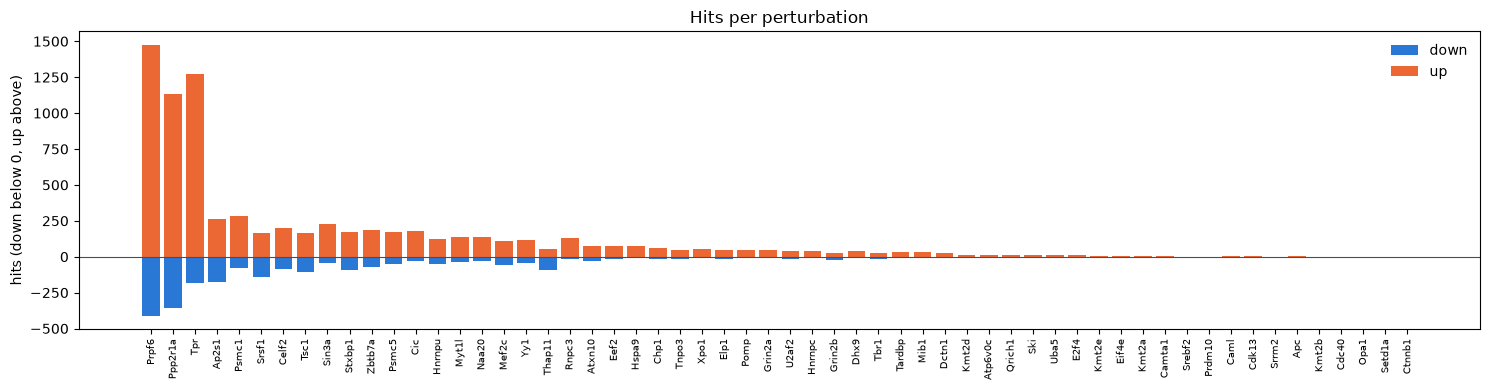

Spearman correlation of hits with arm size: 0.02


In [5]:
tested = df[np.isfinite(df['stat'])].copy()
tested['hit'] = tested['padj'] < Q
hits = tested[tested['hit']]

display(pd.Series({
    'gene x perturbation pairs tested': len(tested),
    'hits': len(hits),
    'perturbations with >= 1 hit': f"{hits['trt'].nunique()} / {A.shape[1]}",
    'hits that are down-regulated': f"{(hits['tau'] < 0).mean():.0%}",
    'hits with zero counts in the perturbed arm': int((hits['count_treated'] == 0).sum()),
    'median |tau| of hits': round(hits['tau'].abs().median(), 2),
}, name=TAG).to_frame())

per_pert = pd.DataFrame({
    'down': hits[hits['tau'] < 0].groupby('trt').size(),
    'up': hits[hits['tau'] > 0].groupby('trt').size(),
}).reindex(A.columns).fillna(0).astype(int)
per_pert['hits'] = per_pert.sum(1)
per_pert['cells'] = n_pert.reindex(per_pert.index).astype(int)
per_pert = per_pert.sort_values('hits', ascending=False)

fig, ax = plt.subplots(figsize=(15, 4))
x = np.arange(len(per_pert))
ax.bar(x, -per_pert['down'], color=BLUE, label='down')
ax.bar(x, per_pert['up'], color=ORANGE, label='up')
ax.axhline(0, color='0.3', lw=0.8)
ax.set_xticks(x, per_pert.index, rotation=90, fontsize=7)
ax.set_ylabel('hits (down below 0, up above)'); ax.legend(frameon=False)
ax.set_title('Hits per perturbation')
plt.tight_layout(); plt.show()
print(f"Spearman correlation of hits with arm size: "
      f"{stats.spearmanr(per_pert['hits'], per_pert['cells']).statistic:.2f}")

**Conclusion.** causarray finds 9,981 hits in 56 of the 58 perturbations, none of them from an arm with zero counts of the gene. Three quarters are up-regulated. The number of hits does not follow the number of cells (Spearman 0.02; the arms have 68–227 cells), so a perturbation's hit count reflects how strongly it changes expression. Three perturbations stand apart, Prpf6, Ppp2r1a and Tpr with about 1,500–1,900 hits each, followed by Ap2s1 (439), Psmc1 (360) and Srsf1 (304).

## 4. Check calibration on fake perturbations

Before reading the effects biologically, check the test on this cell type.
Take control cells only and label random subsets of them as fake
perturbations, with sizes drawn from the real arms (68–227 cells); each random
draw (seed) gives 10. Nothing differs between the arms, so the test statistics
should look like N(0, 1), the p-values should be flat, and hits should be rare.
Wilcoxon on the same fake labels and genes is shown for reference.

### Why `min_counts = 20`

With the package default (`min_counts = 5`, about 5 counts expected in the
perturbed arm) a few hits on fake perturbations appear in genes that are nearly absent from
these neurons, where a handful of stray counts in 100 cells gives a large fold
change. The table applies each threshold to the same
fake perturbations (seeds 0–2) and to the real ones.

In [6]:
from statsmodels.stats.multitest import multipletests

def load_null(seeds, lfc_dir):
    """causarray and Wilcoxon on the fake perturbations, both on the genes causarray tests."""
    ca = pd.concat([pd.read_csv(f'{lfc_dir}/null/seed{s}.csv') for s in seeds], ignore_index=True)
    wc = pd.concat([pl.wilcoxon_table(f'results/{TAG}/null/wilcoxon_seed{s}.h5ad') for s in seeds],
                   ignore_index=True)
    return pl.wilcoxon_on(ca, wc)

def apply_min_counts(d, mc):
    """Keep pairs passing LFC's expression threshold at min_counts=mc, then redo BH per perturbation."""
    d = d[np.isfinite(d['stat'])].copy()
    thr = mc / np.minimum(d['n_treated'], d['n_control'])
    observed = np.maximum(d['count_treated'] / d['n_treated'], d['count_control'] / d['n_control'])
    d = d[(np.maximum(d['mean_control'], d['mean_treated']) >= thr) & (observed >= thr)].copy()
    d['padj'] = d.groupby('trt')['pvalue'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
    return d

null5 = load_null([0, 1, 2], f'results/{TAG}/min_counts5')
real5 = pd.read_csv(f'results/{TAG}/min_counts5/lfc.csv')
rows = []
for mc in (5, 10, 20, 40):
    n, r = apply_min_counts(null5, mc), apply_min_counts(real5, mc)
    fh = n[n['padj'] < Q]
    rows.append({'min_counts': mc,
                 'fake: hits (30 arms)': len(fh),
                 'fake: hits in genes < 0.05 counts/control cell': int((fh['mean_control'] < 0.05).sum()),
                 'real: hits': int((r['padj'] < Q).sum())})
display(pd.DataFrame(rows).set_index('min_counts'))

,fake: hits (30 arms),fake: hits in genes < 0.05 counts/control cell,real: hits
min_counts,,,
5,54,30,10514
10,32,12,10236
20,21,2,9981
40,11,1,9653


**Conclusion.** With the default, 30 of the 54 hits on fake perturbations sit in genes with fewer than 0.05 counts per control cell, mostly glial and immune genes that are nearly absent from these neurons. `min_counts = 20` removes those (2 left) and cuts those hits overall by more than half (54 → 21), at the cost of 5% of the real hits (10,514 → 9,981). Raising it further gains little. **The pipeline uses `min_counts = 20` for all cell types.**

### Calibration at `min_counts = 20`, on fake perturbations not used to choose it

290,450 tests (gene x fake perturbation); BH within each fake perturbation


,hits on 30 fake perturbations,p < 0.05 (expected 5%)
causarray,14,5.8%
Wilcoxon,4,5.2%


causarray z under the null: mean 0.02, SD 1.03 (target 0 and 1)


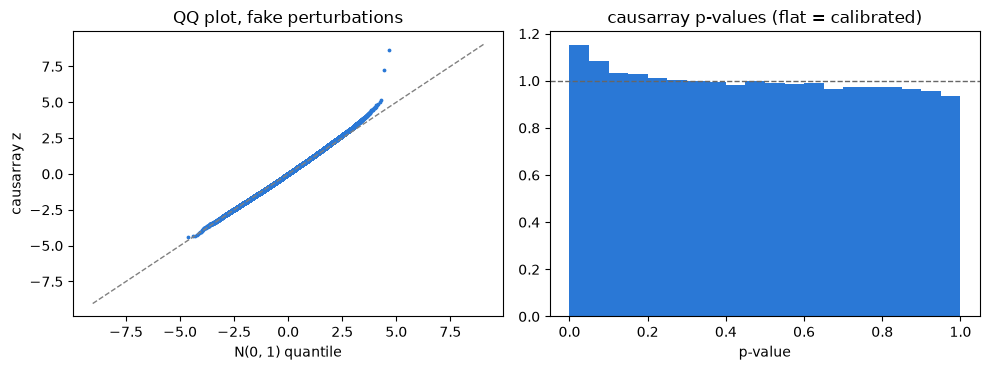

In [7]:
null_check = load_null([3, 4, 5], RUN_DIR)
print(f'{len(null_check):,} tests (gene x fake perturbation); BH within each fake perturbation')
display(pd.DataFrame({
    method: {'hits on 30 fake perturbations': int((null_check[padj] < Q).sum()),
             'p < 0.05 (expected 5%)': f"{(null_check[p] < 0.05).mean():.1%}"}
    for method, p, padj in (('causarray', 'pvalue', 'padj'), ('Wilcoxon', 'wilcox_pvalue', 'wilcox_padj'))
}).T)
print(f"causarray z under the null: mean {null_check['stat'].mean():.2f}, SD {null_check['stat'].std():.2f} (target 0 and 1)")

z = np.sort(null_check['stat'].to_numpy())
theo = stats.norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))
bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(theo, z, s=3, color=BLUE, rasterized=True)
lim = max(abs(theo).max(), abs(z).max()) * 1.05
axes[0].plot([-lim, lim], [-lim, lim], color='0.5', lw=1, ls='--')
axes[0].set_xlabel('N(0, 1) quantile'); axes[0].set_ylabel('causarray z')
axes[0].set_title('QQ plot, fake perturbations')
axes[1].hist(null_check['pvalue'].dropna(), bins=bins, color=BLUE, density=True)
axes[1].axhline(1, color='0.4', lw=1, ls='--')
axes[1].set_xlabel('p-value'); axes[1].set_title('causarray p-values (flat = calibrated)')
plt.tight_layout(); plt.show()

**Conclusion.** On fake perturbations that were not used to choose the threshold, causarray's statistics are close to N(0, 1) (mean 0.02, SD 1.03), and 5.8% of its p-values fall below 0.05 (Wilcoxon 5.2%). causarray makes 14 hits across the 30 fake perturbations, about one every two, while a real perturbation here averages about 170; Wilcoxon makes 4 on the same genes.

The two columns measure different things. The share of p < 0.05 describes the bulk of the p-values. A hit after BH needs a much smaller p-value, about 0.05 / 10,000 = 5e-6 in an arm of 10,000 genes, so the hit count depends only on the few smallest p-values. The QQ plot stays close to the diagonal, with a slightly longer upper tail (the 99th percentile of z is 2.50 against 2.33). The QC table in section 7 reports these numbers for every cell type.

## 5. What the screen shows

### 5a. Which perturbations share a response

Two perturbations that act through the same pathway should move the same genes
in the same direction. The heatmap correlates `tau` between perturbations over
the genes that are a hit for at least one of them (perturbations with at least
50 hits).

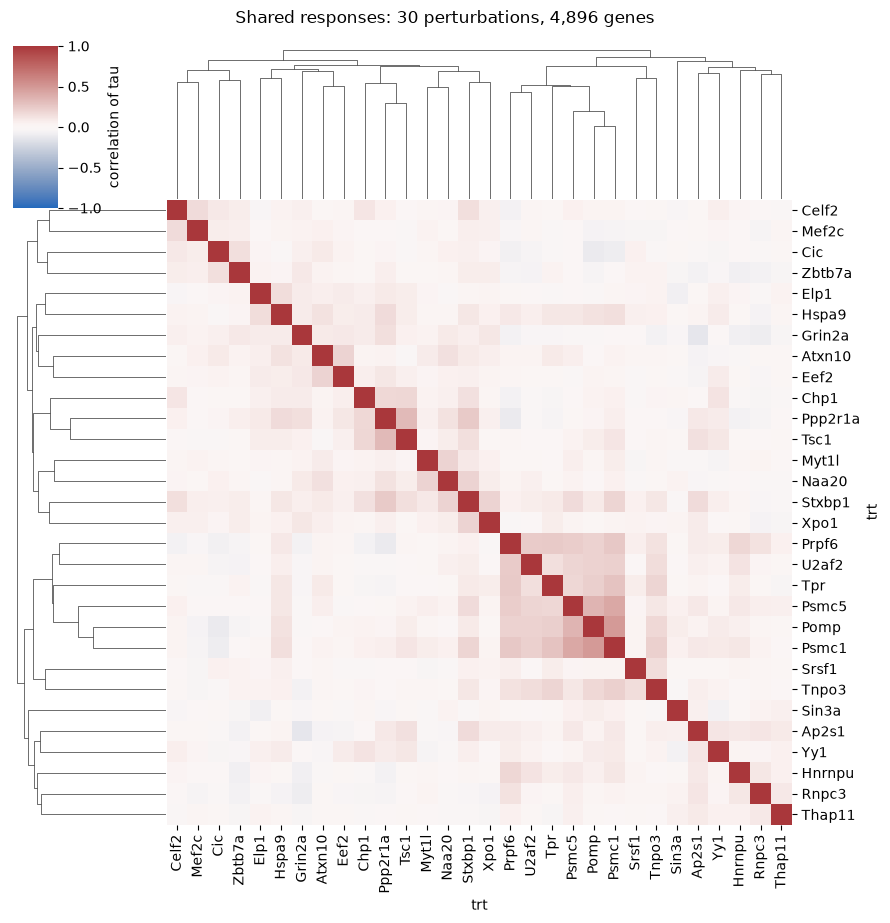

most similar pairs:


,,correlation of tau
trt,trt,
Pomp,Psmc1,0.49
Psmc1,Psmc5,0.41
Pomp,Psmc5,0.35
Ppp2r1a,Tsc1,0.33
Psmc1,Tpr,0.28
Prpf6,Psmc1,0.25
Ppp2r1a,Stxbp1,0.25
Prpf6,Tpr,0.24


In [8]:
strong = per_pert.index[per_pert['hits'] >= 50].tolist()
hit_genes = hits['gene_names'].unique()
T = (tested[tested['trt'].isin(strong) & tested['gene_names'].isin(hit_genes)]
     .pivot(index='gene_names', columns='trt', values='tau').dropna())
C = T.corr()
g = sns.clustermap(C, cmap='vlag', vmin=-1, vmax=1, figsize=(9, 9),
                   cbar_kws={'label': 'correlation of tau'})
g.fig.suptitle(f'Shared responses: {len(strong)} perturbations, {len(T):,} genes', y=1.02)
plt.show()

upper = C.where(np.triu(np.ones(C.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
print('most similar pairs:')
display(upper.head(8).round(2).to_frame('correlation of tau'))

**Conclusion.** The clearest module is the proteasome: its subunits Pomp, Psmc1 and Psmc5 give the three most similar responses (correlation 0.35–0.49), as expected for parts of one complex. In the clustered heatmap they form one block with the RNA-processing perturbations Prpf6, U2af2 (another splicing factor) and Tpr (pairwise correlations 0.24–0.28 with Psmc1), so disrupting protein turnover and RNA processing moves a common set of genes. Separately, Ppp2r1a (the PP2A scaffold) resembles Tsc1 (0.33) and Stxbp1 (0.25). Most other pairs are only weakly related, so each perturbation largely has its own profile.

### 5b. Genes that many perturbations move

A gene hit by many perturbations is part of a common response of these neurons,
rather than a target of one pathway.

In [9]:
by_gene = hits.groupby('gene_names').agg(
    perturbations=('trt', 'nunique'),
    fraction_down=('tau', lambda t: round((t < 0).mean(), 2)),
    median_tau=('tau', lambda t: round(t.median(), 2)),
).sort_values('perturbations', ascending=False)
print(f"genes hit by >= 10 perturbations: {(by_gene['perturbations'] >= 10).sum()} "
      f"(of {len(by_gene):,} genes with any hit)")
display(by_gene.head(20))

genes hit by >= 10 perturbations: 12 (of 5,861 genes with any hit)


,perturbations,fraction_down,median_tau
gene_names,,,
Scube1,14,0.93,-0.27
Snhg11,14,0.57,-0.04
Ahi1,12,0.92,-0.23
Atp1a1,12,1.00,-0.15
Rsrp1,12,0.50,-0.01
R3hdm1,11,0.73,-0.14
Adgrb1,11,0.73,-0.11
Amy1,11,0.18,0.34
Coro6,10,0.60,-0.25


**Conclusion.** Few genes respond to many perturbations: 12 of the 5,861 genes with any hit are hit by 10 or more. Among them, the activity-regulated neurotrophin Bdnf and the neuropeptide Adcyap1 (PACAP) go up in most of the perturbations that hit them, while the sodium pump subunit Atp1a1 and Scube1 and Ahi1 go down. This suggests a common response of these neurons to disruption, on top of each perturbation's specific effects; the correlations in 5a stay low because this shared part is small.

### 5c. What the strongest perturbations change

Enrichr (GO Biological Process, KEGG, Reactome) on the down- and up-regulated
hits of the four perturbations with the most hits, separately.

In [10]:
import re, time, requests
from pathlib import Path

ENRICH_DIR = Path(RUN_DIR) / 'enrichr'
ENRICH_DIR.mkdir(parents=True, exist_ok=True)
LIBS = ('GO_Biological_Process_2023', 'KEGG_2019_Mouse', 'Reactome_2022')

def enriched_terms(genes, cache_name):
    """Enrichr terms with adjusted p < 0.05 (cached per gene list; delete the cache if the list changes)."""
    path = ENRICH_DIR / f'{cache_name}.csv'
    if path.exists():
        return pd.read_csv(path)
    rows = []
    genes = list(genes)
    if len(genes) >= 5:
        r = requests.post('https://maayanlab.cloud/Enrichr/addList',
                          files={'list': (None, '\n'.join(genes)), 'description': (None, cache_name)}, timeout=60)
        r.raise_for_status()
        uid = r.json()['userListId']
        for lib in LIBS:
            for attempt in range(3):
                try:
                    e = requests.get('https://maayanlab.cloud/Enrichr/enrich',
                                     params={'userListId': uid, 'backgroundType': lib}, timeout=60)
                    e.raise_for_status()
                    break
                except requests.RequestException:
                    time.sleep(2)
            rows += [{'lib': lib, 'term': re.sub(r' \(GO:\d+\)| R-HSA-\d+', '', t[1]), 'padj': t[6]}
                     for t in e.json().get(lib, []) if t[6] < 0.05]
    out = pd.DataFrame(rows, columns=['lib', 'term', 'padj']).sort_values('padj')
    out.to_csv(path, index=False)
    return out

FOCUS = per_pert.index[:4].tolist()
rows = []
for trt in FOCUS:
    h = hits[hits['trt'] == trt]
    for direction, genes in (('down', h.loc[h['tau'] < 0, 'gene_names']),
                             ('up', h.loc[h['tau'] > 0, 'gene_names'])):
        terms = enriched_terms(genes, f'{trt}_{direction}')
        rows.append({'perturbation': trt, 'direction': direction, 'genes': len(genes),
                     'enriched terms': len(terms),
                     'top terms': '; '.join(f"{t[:45]} [{p:.0e}]" for t, p in
                                            terms[['term', 'padj']].head(3).itertuples(index=False))
                                  or '(none)'})
with pd.option_context('display.max_colwidth', 160):
    display(pd.DataFrame(rows).set_index(['perturbation', 'direction']))

genes  enriched terms  \
perturbation direction                          
Prpf6        down         412             164   
             up          1475             707   
Ppp2r1a      down         355             137   
             up          1131               4   
Tpr          down         184              42   
             up          1273             279   
Ap2s1        down         173              83   
             up           266               8   

                                                                                                                                                                top terms  
perturbation direction                                                                                                                                                     
Prpf6        down                                          Neuronal System [4e-19]; Transmission Across Chemical Synapses [9e-11]; Chemical Synaptic Transmission [1e-09]  
             up                                   Metabolism Of RNA [2e-60]; Processing Of Capped Intron-Containing Pre-mR [4e-43]; mRNA Splicing - Major Pathway [5e-35]  
Ppp2r1a      down                                                      Neuronal System [5e-08]; Signaling By NTRKs [5e-06]; Transmission Across Chemical Synapses [2e-05]  
             up                                                     Neuronal System [2e-06]; Protein-protein Interactions At Synapses [2e-02]; Potassium Channels [2e-02]  
Tpr          down                                               Neuronal System [3e-04]; Regulation Of Neuron Projection Development [6e-03]; Ca-dependent Events [1e-02]  
             up                                               Gene Expression (Transcription) [1e-12]; RNA Polymerase II Transcription [3e-10]; Metabolism Of RNA [6e-10]  
Ap2s1        down                                       Nuclear Events (Kinase And Transcription Fact [5e-08]; Signaling By NTRK1 (TRKA) [1e-06]; Neuronal System [1e-06]  
             up         Regulation Of Potassium Ion Transport [4e-02]; Positive Regulation Of Developmental Growth [4e-02]; Positive Regulation Of Axon Extension [4e-02]

**Conclusion.** Prpf6 and Tpr up-regulate their own machinery, and Prpf6, Tpr and Ppp2r1a down-regulate neuronal programs:

* **Prpf6** (spliceosome): up-regulated genes enrich for RNA metabolism and mRNA splicing (p = 2e-60); down-regulated genes for the neuronal system and synaptic transmission (4e-19).
* **Tpr** (nuclear pore): up for transcription and RNA polymerase II (1e-12); down for the neuronal system and neuron projection development.
* **Ppp2r1a** (PP2A): down for the neuronal system and neurotrophin (NTRK) signalling; its many up-regulated genes enrich only weakly (4 terms).
* **Ap2s1** (AP-2 adaptor, which internalizes receptors): down for kinase and transcription-factor signalling and NTRK1 (TrkA) signalling, consistent with the role of endocytosis in neurotrophin receptor signalling.

The up-regulation of splicing and transcription genes after knocking down those very processes looks like a compensatory response; the shared loss of synaptic genes fits the common response in 5b.

## 6. Comparison with other methods

causarray is compared with four other methods on the same cells, each testing
every perturbation against the pooled controls:

| method | data it tests | adjusts for latent factors |
|---|---|---|
| causarray | counts (negative-binomial outcome model, size factors) | yes |
| NB GLM, no latent factors | counts, with causarray's size factors | no |
| DESeq2 (pydeseq2) | counts, with poscounts size factors | no |
| Wilcoxon rank-sum | log-normalized counts | no |
| Welch t-test | log-normalized counts | no |

The NB GLM is causarray's count model without its adjustment, so the difference
between the two shows what the latent factors and weighting change. DESeq2 is the
count-based method most groups use; it runs with pydeseq2's defaults except
poscounts size factors, which sparse single-cell data need. Wilcoxon and the
t-test work on log-normalized counts.

All methods are scored on the genes causarray tests, with BH applied within each
perturbation over those genes (`pl.methods_on`). The other methods run once per
cell type and are cached (`pl.run_nb_glm`, `pl.run_deseq2`, `pl.run_ttest`);
DESeq2 takes about 25 minutes and needs `pip install pydeseq2` to recompute.

### Five methods side by side

In [11]:
cmp_all = pl.methods_on(tested, TAG, res_2)
bands = pd.cut(cmp_all['mean_control'], [0, 0.2, 1, 5, np.inf], right=False,
               labels=['< 0.2', '0.2–1', '1–5', '>= 5'])
ca_hit = cmp_all['padj'] < Q
rows = {}
for method, (lfc, padj) in pl.METHODS.items():
    hit, down = cmp_all[padj] < Q, cmp_all[lfc] < 0
    rows[method] = {
        'hits': int(hit.sum()),
        '% down': round(100 * down[hit].mean()),
        **{f'% down, {b} counts/cell': round(100 * down[hit & (bands == b)].mean()) for b in bands.cat.categories},
        'causarray hits it also calls': f"{(hit & ca_hit).sum() / ca_hit.sum():.0%}",
        'its hits causarray also calls': f"{(hit & ca_hit).sum() / hit.sum():.0%}",
        'correlation of log fold change with causarray': round(cmp_all[['tau', lfc]].corr().iloc[0, 1], 2),
    }
display(pd.DataFrame(rows).T)

,hits,% down,"% down, < 0.2 counts/cell","% down, 0.2–1 counts/cell","% down, 1–5 counts/cell","% down, >= 5 counts/cell",causarray hits it also calls,its hits causarray also calls,correlation of log fold change with causarray
causarray,9981,24,1,11,29,62,100%,100%,1.0
"NB GLM, no latent factors",10139,21,1,11,27,63,75%,74%,0.93
DESeq2,6000,27,0,7,31,74,48%,80%,0.85
Wilcoxon,4549,38,2,22,49,79,39%,86%,0.93
"t-test, log-normalized",3826,56,42,56,52,75,30%,77%,0.93


**Conclusion.** The methods split by the data they test, not by whether they adjust for latent factors. The three count-based methods find mostly up-regulated hits (causarray 24% down, the NB GLM without latent factors 21%, DESeq2 27%) and agree band by band: in genes with 1–5 counts per control cell 29%, 27% and 31% of their hits go down, and in genes with at least 5 counts 62%, 63% and 74%. The two tests on log-normalized counts call fewer genes and more decreases (Wilcoxon 38% down, the t-test 56%). So causarray's majority of up-regulated hits does not come from its adjustment: the same count model without it finds as many hits (10,139) in the same directions. In a count model a decrease leaves fewer counts and is harder to detect, while the log scale treats increases and decreases more evenly (the subsection on up and down hits below shows this for Wilcoxon); neither choice is ground truth.

causarray agrees most with the count-based methods: it shares 75% of its hits with the NB GLM, and 80% of DESeq2's hits are causarray hits. Its log fold changes correlate at 0.85–0.93 with every method. The NB GLM and causarray each call about a quarter of hits the other does not; that is the part of the result the latent factors and weighting change.

### Hits per perturbation, all methods

One row per method, with the perturbations in the same order (by causarray hits)
and on the same scale; down-regulated hits are below zero and up-regulated hits
above.

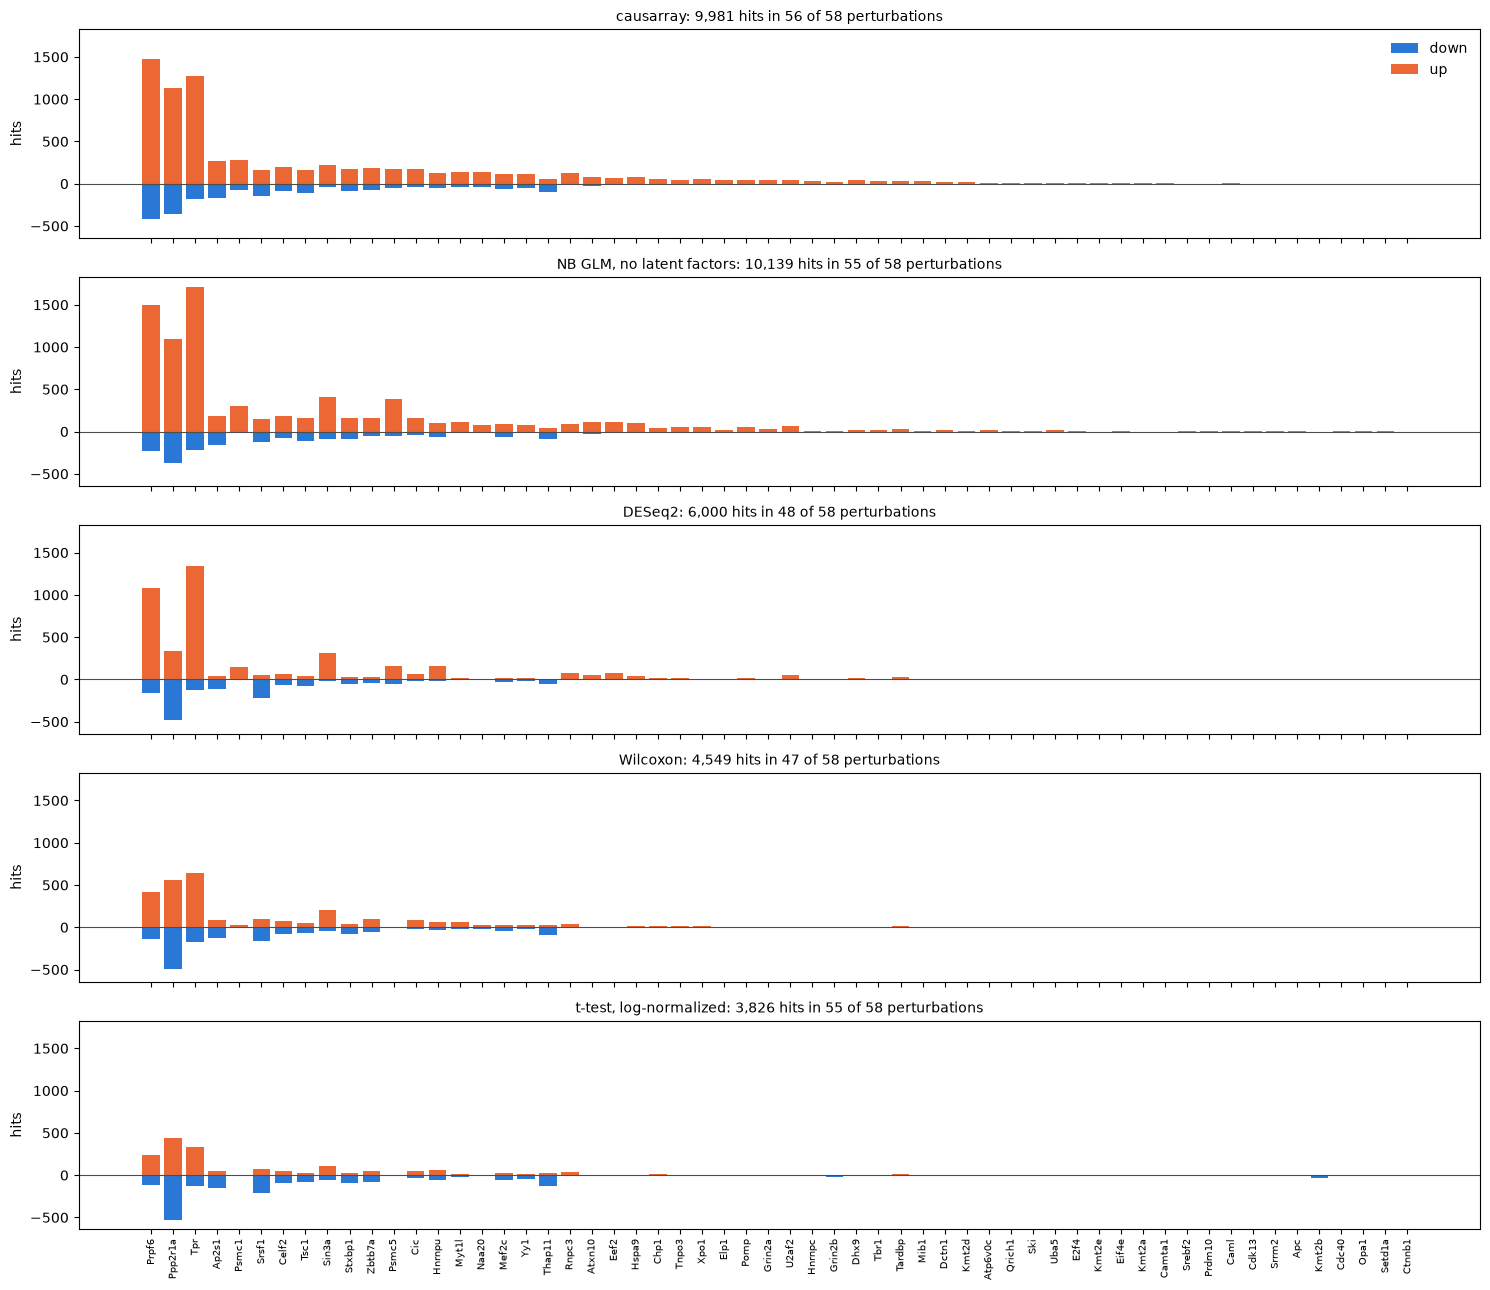

,perturbations with >= 1 hit,median hits per perturbation,Spearman correlation with causarray (hits per perturbation),three perturbations with most hits
causarray,56,54,1.00,"Prpf6, Ppp2r1a, Tpr"
"NB GLM, no latent factors",55,36,0.95,"Tpr, Prpf6, Ppp2r1a"
DESeq2,48,13,0.90,"Tpr, Prpf6, Ppp2r1a"
Wilcoxon,47,8,0.87,"Ppp2r1a, Tpr, Prpf6"
"t-test, log-normalized",55,8,0.70,"Ppp2r1a, Tpr, Prpf6"


In [12]:
order = per_pert.index
x = np.arange(len(order))
hits_by_method = {}
fig, axes = plt.subplots(len(pl.METHODS), 1, figsize=(15, 2.6 * len(pl.METHODS)), sharex=True, sharey=True)
for ax, (method, (lfc, padj)) in zip(axes, pl.METHODS.items()):
    hit = cmp_all[padj] < Q
    up = (hit & (cmp_all[lfc] > 0)).groupby(cmp_all['trt']).sum().reindex(order, fill_value=0)
    down = (hit & (cmp_all[lfc] < 0)).groupby(cmp_all['trt']).sum().reindex(order, fill_value=0)
    hits_by_method[method] = up + down
    ax.bar(x, -down, color=BLUE, label='down')
    ax.bar(x, up, color=ORANGE, label='up')
    ax.axhline(0, color='0.3', lw=0.8)
    ax.set_ylabel('hits')
    ax.set_title(f"{method}: {int((up + down).sum()):,} hits in {int(((up + down) > 0).sum())} "
                 f"of {len(order)} perturbations", fontsize=10)
axes[0].legend(frameon=False)
axes[-1].set_xticks(x, order, rotation=90, fontsize=7)
plt.tight_layout(); plt.show()

hits_by_method = pd.DataFrame(hits_by_method)
display(pd.DataFrame({
    'perturbations with >= 1 hit': (hits_by_method > 0).sum(),
    'median hits per perturbation': hits_by_method.median().astype(int),
    'Spearman correlation with causarray (hits per perturbation)': hits_by_method.corr(method='spearman')['causarray'].round(2),
    'three perturbations with most hits': [', '.join(hits_by_method[m].nlargest(3).index) for m in hits_by_method],
}))

**Conclusion.** All five methods put the same three perturbations at the top (Prpf6, Ppp2r1a and Tpr, in different orders), and their hit counts per perturbation follow causarray's closely: Spearman 0.95 for the NB GLM, 0.90 for DESeq2, 0.87 for Wilcoxon and 0.70 for the t-test. The methods differ mainly in how far their power reaches: the median perturbation has 54 causarray hits, 36 NB GLM hits, 13 DESeq2 hits and 8 for each test on log-normalized counts. Direction differs for a few perturbations: Ppp2r1a and Srsf1 have more down- than up-regulated hits with DESeq2 and the t-test, and are near even (Ppp2r1a) or down (Srsf1) with Wilcoxon, but have more up-regulated hits with causarray and the NB GLM.

### Effects per perturbation: causarray versus DESeq2

The same panels as for Wilcoxon below, with DESeq2's log2 fold change on the x
axis: red for hits of both methods, amber for causarray only, blue for DESeq2
only and grey for neither, with y = x dashed.

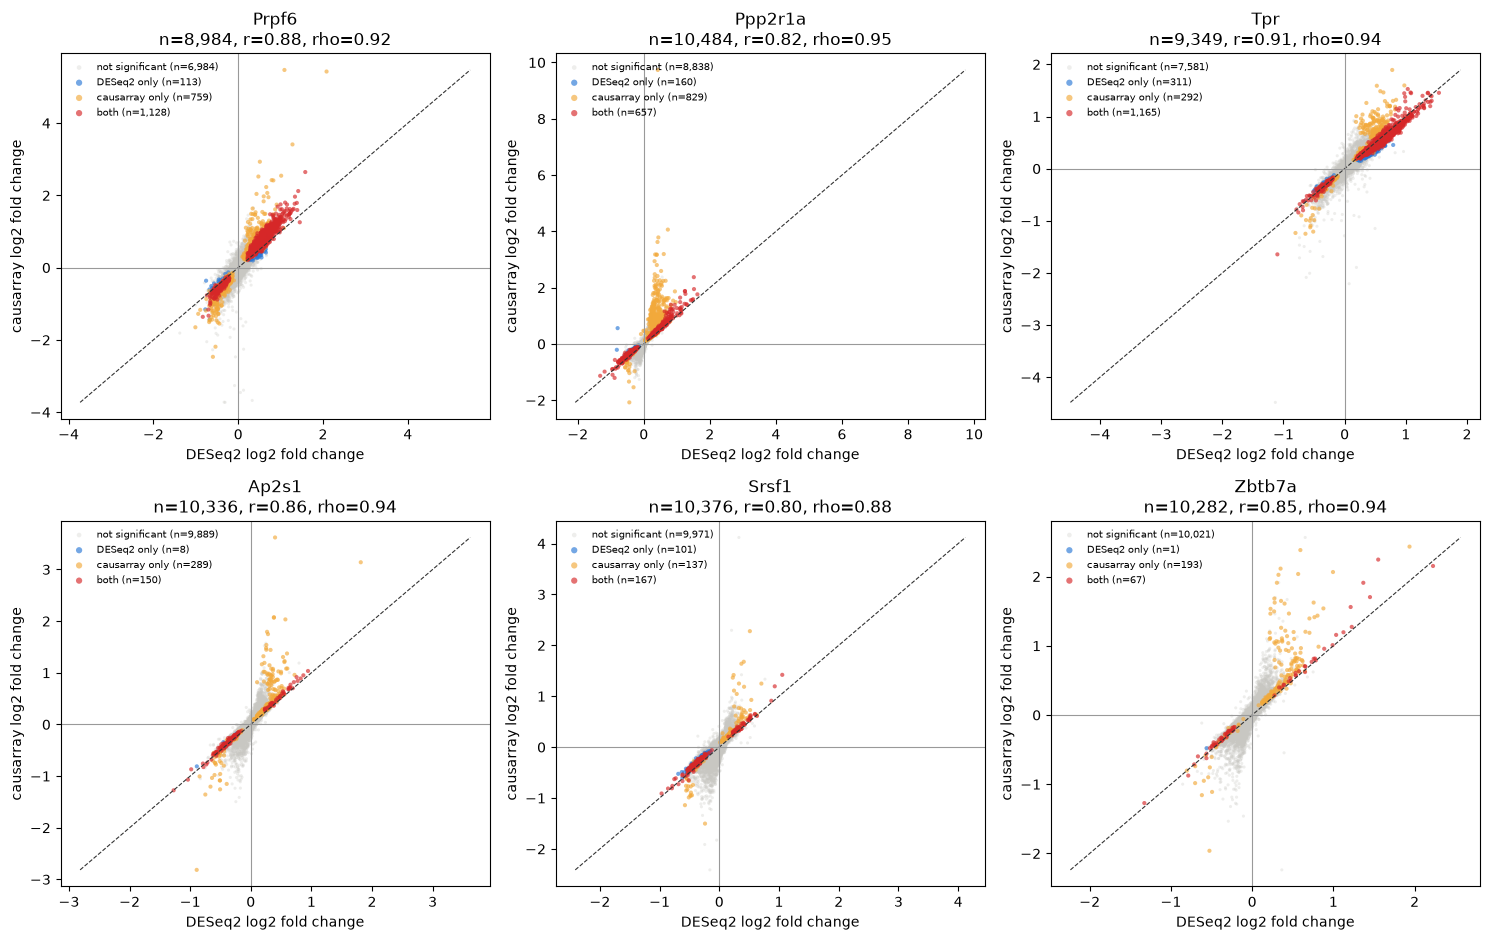

,genes,Pearson r,Spearman rho,DESeq2 log2FC range,causarray log2FC range
perturbation,,,,,
Prpf6,8984,0.88,0.92,-1.4 to 2.1,-3.7 to 5.5
Ppp2r1a,10484,0.82,0.95,-1.3 to 1.6,-2.1 to 9.7
Tpr,9349,0.91,0.94,-1.1 to 1.5,-4.5 to 1.9
Ap2s1,10336,0.86,0.94,-1.3 to 1.8,-2.8 to 3.6
Srsf1,10376,0.80,0.88,-1.0 to 1.1,-2.4 to 4.1
Zbtb7a,10282,0.85,0.94,-1.3 to 2.2,-2.2 to 2.6


In [13]:
PANEL_PERTS = ['Prpf6', 'Ppp2r1a', 'Tpr', 'Ap2s1', 'Srsf1', 'Zbtb7a']
ds_hit = cmp_all['deseq2_padj'] < Q
ds_categories = (('not significant', GREY, ~ca_hit & ~ds_hit), ('DESeq2 only', BLUE, ~ca_hit & ds_hit),
                 ('causarray only', AMBER, ca_hit & ~ds_hit), ('both', RED, ca_hit & ds_hit))
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
ds_stats = []
for ax, trt in zip(axes.ravel(), PANEL_PERTS):
    sel = (cmp_all['trt'] == trt) & cmp_all['deseq2_logfc'].notna()
    xv, yv = cmp_all.loc[sel, 'deseq2_logfc'], cmp_all.loc[sel, 'tau'] / np.log(2)
    for label, color, mask in ds_categories:
        m = mask[sel]
        faint = label == 'not significant'
        ax.scatter(xv[m], yv[m], s=5 if faint else 9, alpha=0.3 if faint else 0.65, color=color,
                   edgecolors='none', rasterized=True, label=f'{label} (n={m.sum():,})')
    r, rho = np.corrcoef(xv, yv)[0, 1], stats.spearmanr(xv, yv).statistic
    lim = [min(xv.min(), yv.min()), max(xv.max(), yv.max())]
    ax.plot(lim, lim, color='0.2', lw=0.8, ls='--')
    ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
    ax.set_title(f'{trt}\nn={sel.sum():,}, r={r:.2f}, rho={rho:.2f}')
    ax.set_xlabel('DESeq2 log2 fold change'); ax.set_ylabel('causarray log2 fold change')
    ax.legend(fontsize=7, frameon=False, loc='upper left', markerscale=1.5)
    ds_stats.append({'perturbation': trt, 'genes': int(sel.sum()), 'Pearson r': r, 'Spearman rho': rho,
                     'DESeq2 log2FC range': f'{xv.min():.1f} to {xv.max():.1f}',
                     'causarray log2FC range': f'{yv.min():.1f} to {yv.max():.1f}'})
plt.tight_layout(); plt.show()
display(pd.DataFrame(ds_stats).set_index('perturbation').round(2))

**Conclusion.** causarray and DESeq2 agree on direction and ranking: Spearman rho is 0.88–0.95 across the six perturbations, and the hits of both methods (red) lie along y = x. Pearson r is lower (0.80–0.91) because of one group of genes, causarray-only hits (amber) that rise steeply above the line, where causarray estimates a log2 fold change of 1–4 and DESeq2 one below about 0.5. Across all perturbations, every one of the 275 causarray-only hits more than 1 log2 unit above DESeq2 is a gene with fewer than 0.5 counts per control cell (median 0.06). In genes with at least 0.5 counts per cell the two estimates have the same size (median ratio 0.9–1.0), while below it DESeq2's are 1.4–2.8 times smaller and DESeq2 makes almost no calls (12 hits below 0.2 counts per cell, against causarray's 909). This is consistent with DESeq2's default lower bound of 0.5 on fitted means (`min_mu`), which suits bulk counts but pulls the estimates of weakly expressed single-cell genes toward zero; causarray has had no such bound since version 0.1.0.

### Wilcoxon in detail

Wilcoxon on log-normalized counts is the usual first look at such a screen. It
does not adjust for the latent factors, so the two lists are not expected to
match, but most Wilcoxon hits should be found again and shared hits should move
in the same direction.

The comparison uses the genes causarray tests, and the Wilcoxon p-values are
BH-adjusted over those genes within each perturbation, as causarray's are
(`pl.wilcoxon_on`). crispyx's own adjusted p-values are taken over all 19,070
genes, including genes seen in only one or two cells, to which its Wilcoxon test
gives extreme p-values (down to 1e-46 for a gene in one perturbed cell and no
control). Those genes pass BH and loosen the cutoff for the rest of the arm; on
the fake perturbations at `min_counts = 20` they would raise Wilcoxon's hits from
4 to 99.

,L45Glut
causarray hits,9981
Wilcoxon hits,4549
Wilcoxon hits also found by causarray,86%
shared hits with the same direction,100%
correlation of effect sizes (all tested pairs),0.93


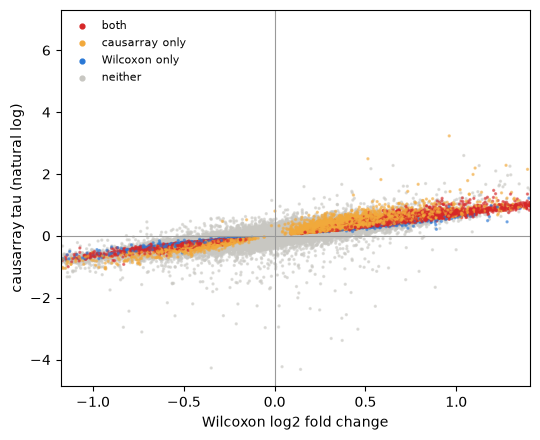

In [14]:
df_wc = pl.run_wilcoxon(TAG)
cmp = pl.wilcoxon_on(tested, df_wc)
cmp['wc'] = cmp['wilcox_padj'] < Q
both = cmp['hit'] & cmp['wc']
display(pd.Series({
    'causarray hits': int(cmp['hit'].sum()),
    'Wilcoxon hits': int(cmp['wc'].sum()),
    'Wilcoxon hits also found by causarray': f"{both.sum() / cmp['wc'].sum():.0%}",
    'shared hits with the same direction': f"{(np.sign(cmp.loc[both, 'tau']) == np.sign(cmp.loc[both, 'wilcox_logfc'])).mean():.0%}",
    'correlation of effect sizes (all tested pairs)': round(cmp[['tau', 'wilcox_logfc']].corr().iloc[0, 1], 2),
}, name=TAG).to_frame())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
c = cmp.iloc[np.argsort((cmp['hit'] | cmp['wc']).to_numpy(), kind='stable')]
colors = np.select([c['hit'] & c['wc'], c['hit'], c['wc']], [RED, AMBER, BLUE], GREY)
ax.scatter(c['wilcox_logfc'], c['tau'], c=colors, s=2, alpha=0.5, rasterized=True)
ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
ax.set_xlim(np.nanpercentile(c['wilcox_logfc'], [0.05, 99.95]))
ax.set_xlabel('Wilcoxon log2 fold change'); ax.set_ylabel('causarray tau (natural log)')
for col, lab in ((RED, 'both'), (AMBER, 'causarray only'), (BLUE, 'Wilcoxon only'), (GREY, 'neither')):
    ax.scatter([], [], color=col, s=12, label=lab)
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

**Conclusion.** The two methods agree where Wilcoxon finds something: causarray recovers 86% of the Wilcoxon hits, every shared hit moves in the same direction, and effect sizes correlate at 0.93. causarray finds about twice as many hits (9,981 vs 4,549). The next three parts look at the direction of the hits, at agreement between lists of equal length, and at what the extra hits contain.

### Hits per perturbation, both methods

The top row repeats causarray's hits per perturbation from section 3; the bottom
row shows Wilcoxon's on the same genes. Both rows use the same perturbation
order (by causarray hits) and the same scale, with down-regulated hits below
zero and up-regulated hits above.

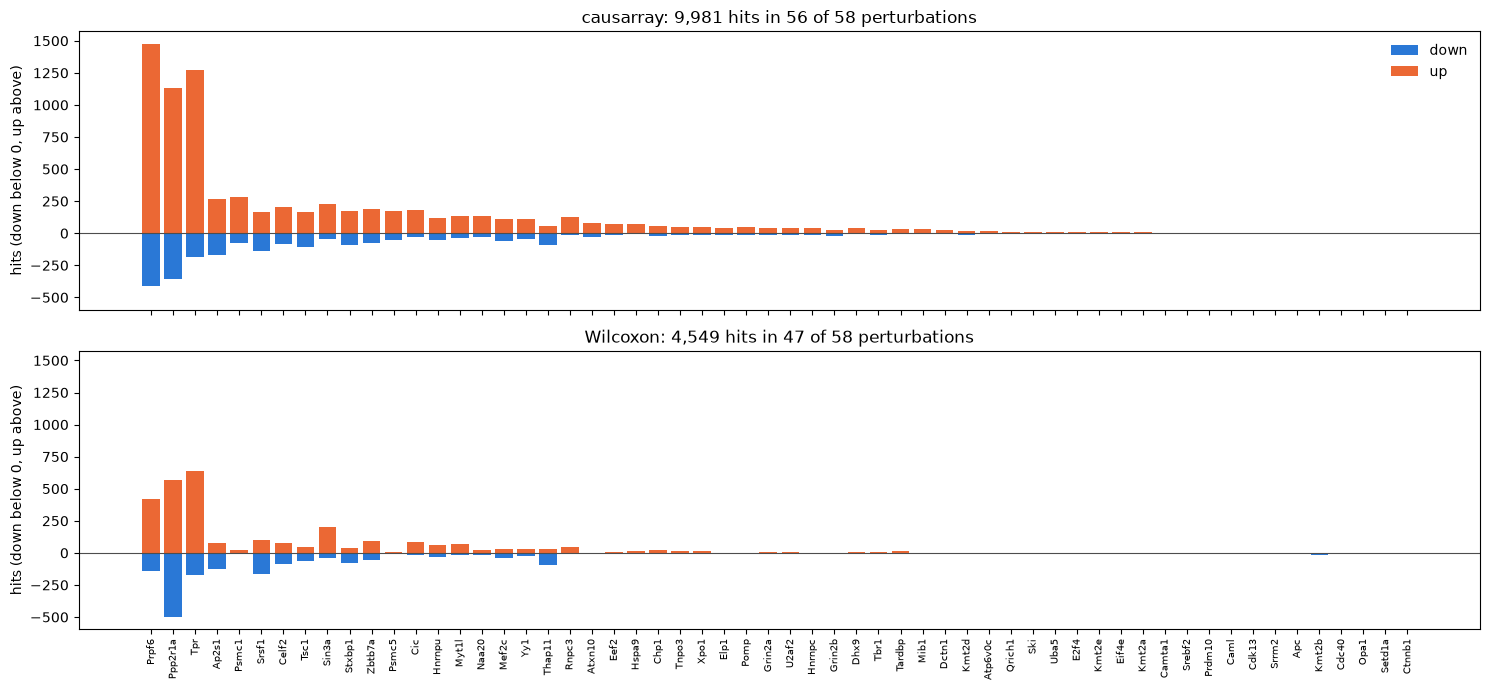

,causarray,Wilcoxon
hits,9981,4549
perturbations with >= 1 hit,56,47
median hits per perturbation,54,8
hits that are down-regulated,24%,38%


Spearman correlation of hits per perturbation between the methods: 0.87
most Wilcoxon hits: Ppp2r1a (1,063), Tpr (810), Prpf6 (561), Srsf1 (265), Sin3a (244)


In [15]:
wc_hits = cmp[cmp['wc']]
per_pert_wc = pd.DataFrame({
    'down': wc_hits[wc_hits['wilcox_logfc'] < 0].groupby('trt').size(),
    'up': wc_hits[wc_hits['wilcox_logfc'] > 0].groupby('trt').size(),
}).reindex(per_pert.index).fillna(0).astype(int)
per_pert_wc['hits'] = per_pert_wc.sum(1)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True, sharey=True)
x = np.arange(len(per_pert))
for ax, (method, counts) in zip(axes, (('causarray', per_pert), ('Wilcoxon', per_pert_wc))):
    ax.bar(x, -counts['down'], color=BLUE, label='down')
    ax.bar(x, counts['up'], color=ORANGE, label='up')
    ax.axhline(0, color='0.3', lw=0.8)
    ax.set_ylabel('hits (down below 0, up above)')
    ax.set_title(f"{method}: {counts['hits'].sum():,} hits in {(counts['hits'] > 0).sum()} of {len(counts)} perturbations")
axes[0].legend(frameon=False)
axes[1].set_xticks(x, per_pert.index, rotation=90, fontsize=7)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    'causarray': [int(per_pert['hits'].sum()), int((per_pert['hits'] > 0).sum()),
                  int(per_pert['hits'].median()), f"{per_pert['down'].sum() / per_pert['hits'].sum():.0%}"],
    'Wilcoxon': [int(per_pert_wc['hits'].sum()), int((per_pert_wc['hits'] > 0).sum()),
                 int(per_pert_wc['hits'].median()), f"{per_pert_wc['down'].sum() / per_pert_wc['hits'].sum():.0%}"],
}, index=['hits', 'perturbations with >= 1 hit', 'median hits per perturbation', 'hits that are down-regulated']))
print(f"Spearman correlation of hits per perturbation between the methods: "
      f"{stats.spearmanr(per_pert['hits'], per_pert_wc['hits']).statistic:.2f}")
print('most Wilcoxon hits:', ', '.join(f'{t} ({n:,})' for t, n in per_pert_wc['hits'].nlargest(5).items()))

**Conclusion.** The two methods rank the perturbations alike: their hit counts per perturbation correlate at 0.87 (Spearman), and the same three perturbations lead both rows (Prpf6, Ppp2r1a and Tpr, with 561–1,063 Wilcoxon hits each). causarray finds hits in 56 perturbations and Wilcoxon in 47, and the median perturbation has 54 causarray hits against 8 Wilcoxon hits, so causarray's extra power reaches the many perturbations with moderate effects, not only the strongest ones.

### Effects per perturbation

The pooled scatter above mixes all perturbations. The panels below show one
perturbation each, with both axes in log2 units (causarray's `tau` divided by
ln 2) and the same colours: red for hits of both methods, amber for causarray
only, blue for Wilcoxon only and grey for neither. The dashed line is y = x.
Each panel shows every gene causarray tests for that perturbation, and its title
gives the number of genes and the Pearson (r) and Spearman (rho) correlations.

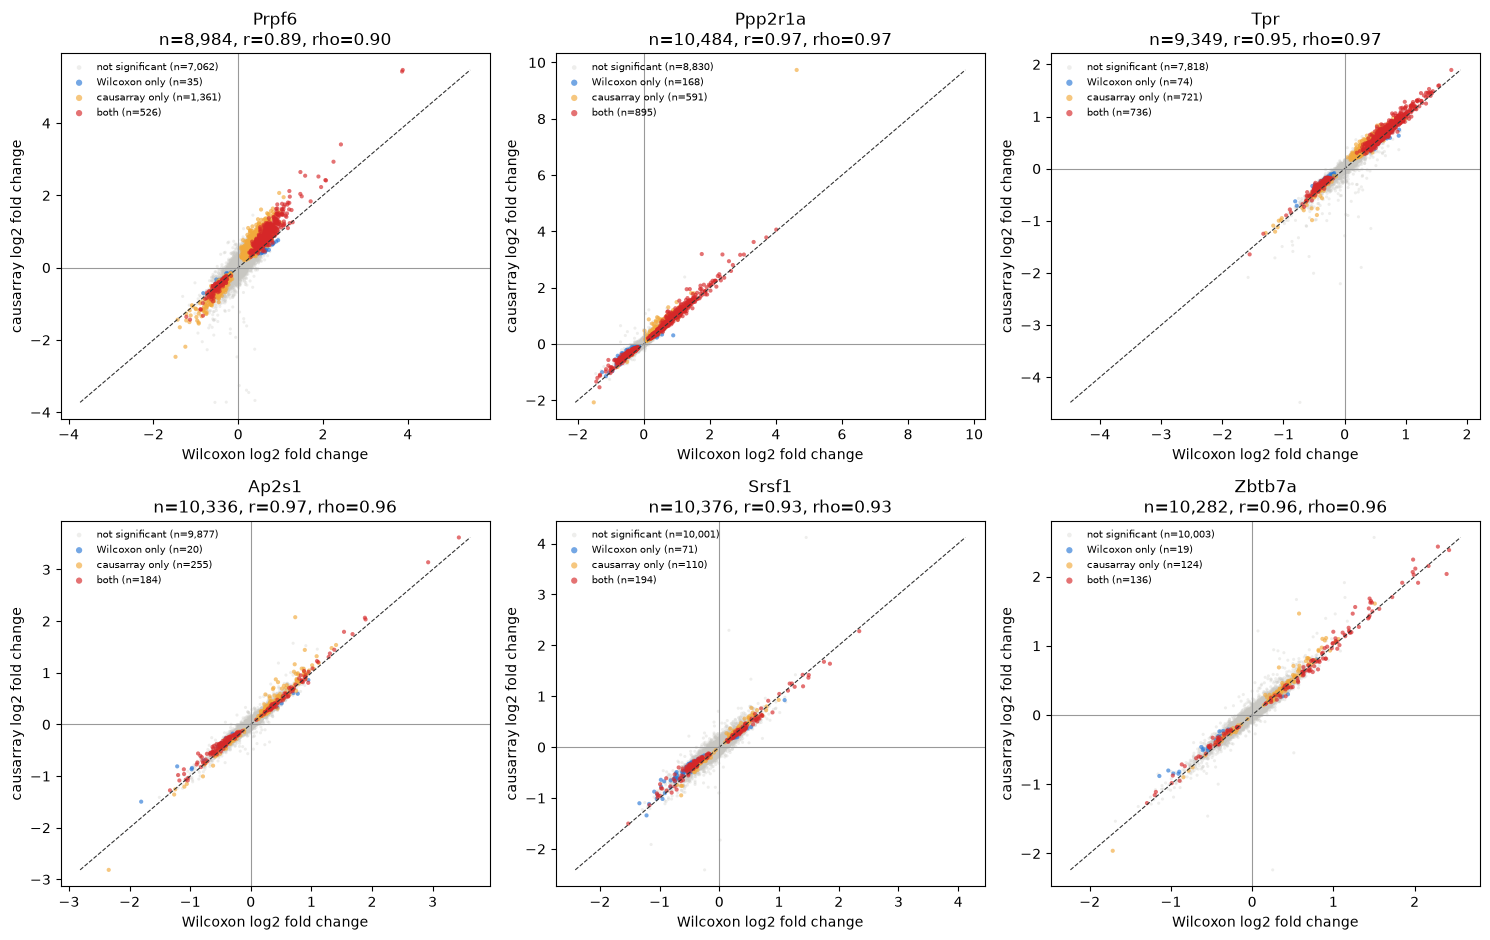

,genes,Pearson r,Spearman rho,Wilcoxon log2FC range,causarray log2FC range
perturbation,,,,,
Prpf6,8984,0.89,0.90,-1.5 to 3.9,-3.7 to 5.5
Ppp2r1a,10484,0.97,0.97,-1.5 to 4.6,-2.1 to 9.7
Tpr,9349,0.95,0.97,-1.6 to 1.7,-4.5 to 1.9
Ap2s1,10336,0.97,0.96,-2.3 to 3.4,-2.8 to 3.6
Srsf1,10376,0.93,0.93,-1.5 to 2.3,-2.4 to 4.1
Zbtb7a,10282,0.96,0.96,-1.7 to 2.4,-2.2 to 2.6


In [16]:
PANEL_PERTS = ['Prpf6', 'Ppp2r1a', 'Tpr', 'Ap2s1', 'Srsf1', 'Zbtb7a']
categories = (('not significant', GREY, ~cmp['hit'] & ~cmp['wc']),
              ('Wilcoxon only', BLUE, ~cmp['hit'] & cmp['wc']),
              ('causarray only', AMBER, cmp['hit'] & ~cmp['wc']),
              ('both', RED, cmp['hit'] & cmp['wc']))

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
panel_stats = []
for ax, trt in zip(axes.ravel(), PANEL_PERTS):
    sel = cmp['trt'] == trt
    x, y = cmp.loc[sel, 'wilcox_logfc'], cmp.loc[sel, 'tau'] / np.log(2)
    for label, color, mask in categories:
        m = mask[sel]
        faint = label == 'not significant'
        ax.scatter(x[m], y[m], s=5 if faint else 9, alpha=0.3 if faint else 0.65, color=color,
                   edgecolors='none', rasterized=True, label=f'{label} (n={m.sum():,})')
    r, rho = np.corrcoef(x, y)[0, 1], stats.spearmanr(x, y).statistic
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, color='0.2', lw=0.8, ls='--')
    ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
    ax.set_title(f'{trt}\nn={sel.sum():,}, r={r:.2f}, rho={rho:.2f}')
    ax.set_xlabel('Wilcoxon log2 fold change'); ax.set_ylabel('causarray log2 fold change')
    ax.legend(fontsize=7, frameon=False, loc='upper left', markerscale=1.5)
    panel_stats.append({'perturbation': trt, 'genes': int(sel.sum()), 'Pearson r': r, 'Spearman rho': rho,
                        'Wilcoxon log2FC range': f'{x.min():.1f} to {x.max():.1f}',
                        'causarray log2FC range': f'{y.min():.1f} to {y.max():.1f}'})
plt.tight_layout(); plt.show()
display(pd.DataFrame(panel_stats).set_index('perturbation').round(2))

**Conclusion.** For every perturbation shown the effects lie along y = x: Pearson r is 0.89–0.97 and Spearman rho 0.90–0.97, and the Wilcoxon log2 fold changes stay between −2.3 and 4.6. Hits of both methods (red) sit at the ends of each cloud; the causarray-only hits (amber) continue the same line toward smaller effects and point in the same direction as Wilcoxon, and the few Wilcoxon-only hits (blue) lie on the line too. For Prpf6 the up-regulated hits sit slightly above the line, where causarray's estimates are the larger of the two. A handful of points lie away from the line; the farthest, Ighg3 under Ppp2r1a (causarray log2 fold change 9.7, Wilcoxon 4.6), rests on 24 counts in the perturbed cells.

### Up and down hits by expression level

Three quarters of the causarray hits are up-regulated. To interpret that,
split the hits by how strongly the gene is expressed in the controls. Count data are not symmetric: a decrease lowers the
perturbed arm's mean, and fewer counts mean a less precise estimate, so a
decrease is harder to detect than an increase of the same size, most of all in
weakly expressed genes. Both methods face this, so the useful comparison is
the two methods within the same expression band.

The first table gives, per band, the hits of each method and the share that go
down. The second compares how often a pair is called when its estimated effect
is 0.35–0.8 on the natural-log scale (about 1.4- to 2.2-fold), separately for
increases and decreases; each method is binned by its own effect estimate.

In [17]:
EXPR_BINS = [0, 0.2, 1, 5, np.inf]
EXPR_LABELS = ['< 0.2', '0.2–1', '1–5', '>= 5']
cmp['expression'] = pd.cut(cmp['mean_control'], EXPR_BINS, right=False, labels=EXPR_LABELS)

def direction_table(d):
    return pd.Series({
        'pairs tested': len(d),
        'median tau': round(d['tau'].median(), 3),
        'causarray hits': int(d['hit'].sum()),
        'causarray % down': round(100 * (d.loc[d['hit'], 'tau'] < 0).mean()),
        'Wilcoxon hits': int(d['wc'].sum()),
        'Wilcoxon % down': round(100 * (d.loc[d['wc'], 'wilcox_logfc'] < 0).mean()),
    })

by_expr = cmp.groupby('expression', observed=True).apply(direction_table)
by_expr.loc['all genes'] = direction_table(cmp)
by_expr = by_expr.astype({c: int for c in by_expr.columns if c != 'median tau'})
by_expr.index.name = 'counts per control cell'
display(by_expr)

effect = {'causarray': (cmp['tau'], cmp['hit']),
          'Wilcoxon': (cmp['wilcox_logfc'] * np.log(2), cmp['wc'])}
rows = {}
for method, (est, called) in effect.items():
    moderate = est.abs().between(0.35, 0.8, inclusive='left')
    for direction, sign in (('up', est > 0), ('down', est < 0)):
        keep = moderate & sign
        rows[(method, direction)] = called[keep].groupby(cmp.loc[keep, 'expression'], observed=True).mean()
called_rate = (100 * pd.DataFrame(rows).T).round(0)
called_rate.index.names = ['method', 'effect']
called_rate.columns.name = 'counts per control cell'
print('% of pairs called, among pairs with an estimated effect of 0.35-0.8 (natural log):')
display(called_rate)

,pairs tested,median tau,causarray hits,causarray % down,Wilcoxon hits,Wilcoxon % down
counts per control cell,,,,,,
< 0.2,31531,0.116,909,1,545,2
0.2–1,306428,0.010,3528,11,1529,22
1–5,207327,0.003,4369,29,1868,49
>= 5,19778,-0.008,1175,62,607,79
all genes,565064,0.008,9981,24,4549,38


% of pairs called, among pairs with an estimated effect of 0.35-0.8 (natural log):


counts per control cell  < 0.2  0.2–1   1–5   >= 5
method    effect                                  
causarray up               8.0   31.0  83.0  100.0
          down             0.0    4.0  48.0   85.0
Wilcoxon  up               5.0   17.0  73.0  100.0
          down             0.0    3.0  45.0   90.0

**Conclusion.** The direction of the hits follows expression level, and both methods show the same pattern. In genes with fewer than 0.2 counts per control cell almost every hit is up (causarray 99%, Wilcoxon 98%); in genes with at least 5 counts per cell most hits are down (causarray 62%, Wilcoxon 79%). The effects themselves are centred: in the bands that hold 94% of the tested pairs (0.2 counts per cell and above) the median tau is within 0.01 of zero, so the up-regulated majority is not a shift of the whole distribution.

The second table shows the reason. At the same effect size both methods call increases more often than decreases, because a decrease leaves fewer counts to measure: in genes with 1–5 counts per cell causarray calls 83% of moderate increases and 48% of moderate decreases, and Wilcoxon 73% and 45%. causarray calls more pairs than Wilcoxon in most bands, and its gain is largest for increases in weakly and moderately expressed genes, which is why its hits include more up-regulated genes (24% down against Wilcoxon's 38%).

### Overlap at equal list lengths

causarray calls about twice as many hits as Wilcoxon, so "what share of the
causarray hits does Wilcoxon also call" is capped at about one half even if the
two methods ranked genes identically. A fairer measure of agreement compares
lists of the same length: for each perturbation take the top *k* genes of each
method by p-value, with *k* the smaller of the two hit counts, and count the
genes both lists share. The table also checks the hits only causarray calls:
whether Wilcoxon estimates them in the same direction, and how many reach
Wilcoxon p < 0.05 before the multiple-testing correction.

In [18]:
overlap_rows = []
for trt, g in cmp.groupby('trt'):
    k = int(min(g['hit'].sum(), g['wc'].sum()))
    if k == 0:
        continue
    top_ca = set(g.nsmallest(k, 'pvalue')['gene_names'])
    top_wc = set(g.nsmallest(k, 'wilcox_pvalue')['gene_names'])
    overlap_rows.append({'trt': trt, 'k': k, 'shared': len(top_ca & top_wc)})
overlap = pd.DataFrame(overlap_rows).set_index('trt')
overlap['overlap'] = overlap['shared'] / overlap['k']

ca_only = cmp[cmp['hit'] & ~cmp['wc']]
display(pd.Series({
    'Wilcoxon hits also called by causarray': f"{(cmp['hit'] & cmp['wc']).sum() / cmp['wc'].sum():.0%}",
    'causarray hits also called by Wilcoxon': f"{(cmp['hit'] & cmp['wc']).sum() / cmp['hit'].sum():.0%}",
    'overlap of equal-length lists (all perturbations pooled)': f"{overlap['shared'].sum() / overlap['k'].sum():.0%}",
    'causarray-only hits in the same direction as Wilcoxon':
        f"{(np.sign(ca_only['tau']) == np.sign(ca_only['wilcox_logfc'])).mean():.0%}",
    'causarray-only hits with Wilcoxon p < 0.05 (unadjusted)': f"{(ca_only['wilcox_pvalue'] < 0.05).mean():.0%}",
}, name=TAG).to_frame())
print('overlap of equal-length lists, perturbations with the most hits:')
display(overlap.loc[[t for t in per_pert.index[:8] if t in overlap.index]].round(2))

,L45Glut
Wilcoxon hits also called by causarray,86%
causarray hits also called by Wilcoxon,39%
overlap of equal-length lists (all perturbations pooled),68%
causarray-only hits in the same direction as Wilcoxon,100%
causarray-only hits with Wilcoxon p < 0.05 (unadjusted),80%


overlap of equal-length lists, perturbations with the most hits:


,k,shared,overlap
trt,,,
Prpf6,561,360,0.64
Ppp2r1a,1063,769,0.72
Tpr,810,566,0.70
Ap2s1,204,132,0.65
Psmc1,26,11,0.42
Srsf1,265,181,0.68
Celf2,162,103,0.64
Tsc1,108,69,0.64


**Conclusion.** Most discoveries are shared. causarray recovers 86% of the Wilcoxon hits; the reverse share (39%) is lower only because causarray calls about twice as many. On lists of equal length the two methods share 68% of their genes, and 64–72% for the four perturbations with the most hits. The hits only causarray calls agree with Wilcoxon's estimates: all of them move in the same direction, and 80% reach Wilcoxon p < 0.05 before correction, so they are mostly effects that Wilcoxon also sees but does not call after correction.

### Which method's extra hits carry biology?

Shared hits say nothing about which method is better, so the checks below look
at the hits only one method calls, for the same four perturbations as in 5c:

* **Exclusive hits.** Enrich the causarray-only and the Wilcoxon-only genes
  separately. Noise should not enrich for anything.
* **Lists of equal length.** Longer lists give more enriched terms whatever their
  quality, so also take each method's top *k* genes, with the same *k* (the
  smaller of the two hit counts), and count the terms.
* **Expression support.** Are each method's exclusive hits well-measured genes,
  or sparse ones where a few counts decide the call?

In [19]:
rows = []
for trt in FOCUS:
    g = cmp[cmp['trt'] == trt]
    k = int(min(g['hit'].sum(), g['wc'].sum()))
    sets = {
        'causarray only': g.loc[g['hit'] & ~g['wc'], 'gene_names'],
        'Wilcoxon only': g.loc[g['wc'] & ~g['hit'], 'gene_names'],
        f'causarray top {k}': g[g['hit']].sort_values('pvalue')['gene_names'].head(k),
        f'Wilcoxon top {k}': g[g['wc']].sort_values('wilcox_pvalue')['gene_names'].head(k),
    }
    for name, genes in sets.items():
        terms = enriched_terms(genes, f"{trt}_{name.replace(' ', '_')}")
        go = terms[terms['lib'] == 'GO_Biological_Process_2023']
        rows.append({'perturbation': trt, 'gene list': name, 'genes': len(genes),
                     'enriched terms': len(terms), 'GO BP terms': len(go),
                     'top GO BP term': f"{go.iloc[0]['term'][:55]} [{go.iloc[0]['padj']:.0e}]" if len(go) else '(none)'})
with pd.option_context('display.max_colwidth', 80):
    display(pd.DataFrame(rows).set_index(['perturbation', 'gene list']))

ca_only, wc_only = cmp['hit'] & ~cmp['wc'], cmp['wc'] & ~cmp['hit']
display(pd.DataFrame({
    'hits': [int(ca_only.sum()), int(wc_only.sum())],
    'median counts in the perturbed arm': [cmp.loc[ca_only, 'count_treated'].median(),
                                           cmp.loc[wc_only, 'count_treated'].median()],
    'median counts per control cell': [round(cmp.loc[ca_only, 'mean_control'].median(), 2),
                                       round(cmp.loc[wc_only, 'mean_control'].median(), 2)],
}, index=['causarray only', 'Wilcoxon only']))

genes  enriched terms  GO BP terms  \
perturbation gene list                                                
Prpf6        causarray only       1361             461          139   
             Wilcoxon only          35               2            2   
             causarray top 561     561             274          101   
             Wilcoxon top 561      561             101           35   
Ppp2r1a      causarray only        591               0            0   
             Wilcoxon only         168               1            0   
             causarray top 1063   1063              90           47   
             Wilcoxon top 1063    1063             138           71   
Tpr          causarray only        721             242           63   
             Wilcoxon only          74              17            0   
             causarray top 810     810             100           49   
             Wilcoxon top 810      810              56           40   
Ap2s1        causarray only        255               0            0   
             Wilcoxon only          20               0            0   
             causarray top 204     204              47           11   
             Wilcoxon top 204      204              32            9   

                                                                                  top GO BP term  
perturbation gene list                                                                            
Prpf6        causarray only                                              mRNA Processing [2e-15]  
             Wilcoxon only                                  Regulation Of Axon Extension [9e-03]  
             causarray top 561                            mRNA Splicing, Via Spliceosome [7e-16]  
             Wilcoxon top 561                             mRNA Splicing, Via Spliceosome [2e-08]  
Ppp2r1a      causarray only                                                               (none)  
             Wilcoxon only                                                                (none)  
             causarray top 1063                           Chemical Synaptic Transmission [2e-06]  
             Wilcoxon top 1063                            Chemical Synaptic Transmission [2e-05]  
Tpr          causarray only                              Peptidyl-Serine Phosphorylation [1e-04]  
             Wilcoxon only                                                                (none)  
             causarray top 810          Regulation Of Transcription By RNA Polymerase II [1e-07]  
             Wilcoxon top 810    Positive Regulation Of Transcription By RNA Polymerase  [4e-05]  
Ap2s1        causarray only                                                               (none)  
             Wilcoxon only                                                                (none)  
             causarray top 204                                Neurotransmitter Secretion [3e-04]  
             Wilcoxon top 204                                 Nervous System Development [3e-03]

,hits,median counts in the perturbed arm,median counts per control cell
causarray only,6068,172.0,1.18
Wilcoxon only,636,141.5,1.06


**Conclusion.** For two of the four perturbations, Prpf6 and Tpr, causarray's extra hits carry the biology and Wilcoxon's barely do; for Ap2s1 neither method's do, and Ppp2r1a goes the other way:

* **Prpf6**: its 1,361 causarray-only genes enrich for RNA metabolism and mRNA splicing (461 terms); its 35 Wilcoxon-only genes give 2 weak terms (axon extension, p = 9e-03). On lists of equal length (561 genes) causarray gives 274 terms against 101, with the same theme at a stronger p-value (RNA metabolism, 9e-26 against 2e-11).
* **Tpr**: its 721 causarray-only genes give 242 terms, led by transcription and RNA polymerase II (2e-08), which matches Tpr's role at the nuclear pore; its 74 Wilcoxon-only genes give 17 weaker terms (mRNA surveillance, 2e-03). On equal lists (810) causarray gives 100 terms against 56, both led by mRNA splicing.
* **Ap2s1**: neither method's exclusive hits enrich; on equal lists (204) causarray gives 47 terms against 32, both led by kinase and transcription-factor signalling and NTRK1 (TrkA) signalling.
* **Ppp2r1a is the exception**: its 591 causarray-only genes (mostly up-regulated) enrich for nothing, and on equal lists (1,063) Wilcoxon gives more terms (138 against 90), both led by the neuronal system. Ppp2r1a's extra up-regulated hits have no annotated theme, so treat them with care.

Across all perturbations, causarray's exclusive hits are, if anything, better measured than Wilcoxon's (median 172 against 142 counts in the perturbed arm; 1.18 against 1.06 per control cell), so the extra hits are not sparse-gene artifacts. Together with the calibration check in section 4 and the agreement above, this suggests that most of causarray's extra power is real signal; Ppp2r1a's extra up-regulated hits are the ones to treat with care.

## 7. Running every cell type

The loop below is the whole analysis for all cell types. It is switched off
here (`RUN_ALL = False`). Every step skips work already on disk, so after a
crash the loop can simply be run again.

What it costs, measured on this cell type (22k cells, 14k genes, 58 perturbations),
with crispyx 0.1.6 (0.1.5 is several times slower):

* **latent factors**: one GCATE fit per cell type, 34 minutes on 32 cores;
* **causarray**: about 5 minutes per batch of 10 perturbations with all 15k controls, running 3 batches at a time on a 32-core, 512 GB machine. **Cap each job's threads when running several at once** (`export NUMBA_NUM_THREADS=10 OMP_NUM_THREADS=10 OPENBLAS_NUM_THREADS=10` for 3 jobs on 32 cores); otherwise the jobs compete for cores and run about ten times slower. A batch can use up to about 90 GB of memory;
* **Wilcoxon**: a few minutes for all perturbations;
* **calibration check**: 3 fake-perturbation batches (seeds 3–5), the same cost as 3 causarray batches.

On an Apple Silicon Mac, use a native (arm64) Python: an Intel Python running under Rosetta is several times slower, and `import causarray` warns about it.

For 1,900 perturbations a cell type has 190 batches. The batches are independent,
so run them as separate jobs, as many at a time as memory allows
(`python pipeline.py lfc --tag <tag> --batches <k>`), then call `pl.run_lfc`
once more to combine them. Memory grows with (cells in the batch) × (genes) ×
(batch size), so use `pl.run_lfc(..., batch_size=5)` for large cell types.

In [20]:
RUN_ALL = False
SRC = 'data/combined.h5ad'          # the full screen, one h5ad with all cell types
CELL_TYPES = {                       # tag -> value of obs['predicted_group']
    'L45Glut': '005 L4-5 IT CTX Glut',
    # 'L23Glut': '...',
}

def run_cell_type(tag, cell_type):
    pl.subset_cell_type(SRC, cell_type, tag)
    Y, A, X, X_A = pl.load_inputs(tag)
    res_2 = pl.fit_factors(tag, Y, X, A)
    df = pl.run_lfc(tag, Y, A, X, X_A, res_2, variant=VARIANT)
    df_wc = pl.run_wilcoxon(tag)
    nulls = [pl.run_null(tag, Y, A, X, X_A, res_2, seed, variant=VARIANT) for seed in (3, 4, 5)]
    return pl.summarize(tag, df, df_wc, nulls)

if RUN_ALL:
    qc = pd.DataFrame([run_cell_type(t, c) for t, c in CELL_TYPES.items()]).set_index('cell type')
else:                                # this cell type, from the cached results
    nulls = [(pd.read_csv(f'{RUN_DIR}/null/seed{s}.csv'),
              pl.wilcoxon_table(f'results/{TAG}/null/wilcoxon_seed{s}.h5ad')) for s in (3, 4, 5)]
    qc = pd.DataFrame([pl.summarize(TAG, df, df_wc, nulls)]).set_index('cell type')
display(qc.T)

cell type,L45Glut
perturbations,58.00
causarray hits,9981.00
Wilcoxon hits,4549.00
Wilcoxon hits recovered,0.86
fraction down,0.24
hits with zero perturbed counts,0.00
fake perturbations: causarray hits,14.00
fake perturbations: Wilcoxon hits,4.00
fake perturbations: SD of z (target 1),1.03


**How to read the QC table.** One row per cell type; look for cell types that
stand out. For reference, this cell type gives:

* 9,981 hits, recovering 86% of the Wilcoxon hits, 24% down-regulated, no hits with zero counts in the perturbed arm;
* fake perturbations: 14 causarray hits over 30 (Wilcoxon 4, on the same genes), SD of z 1.03.

A cell type that fails the calibration check (many hits on fake perturbations, or SD of z well above 1)
should be looked at before its hits are used: start with its propensity check
(section 2), the arms the pipeline adjusted (`lfc_batches/*_propensity.csv`),
and the size of its arms.

## Summary

1. **How to run it.** One GCATE fit per cell type, then `LFC` on all controls plus 10 perturbations at a time, with `min_counts = 20` and threads capped when batches run in parallel. `pipeline.py` does each step and resumes after a crash.
2. **What to check before reading effects.** The propensity check (section 2): here only Tpr needed an adjustment, dropping library size from Tpr's propensity model alone (its outcome model still adjusts for it). The calibration check (section 4): statistics close to N(0, 1) and about one hit every two fake perturbations, against about 170 per real one.
3. **What this cell type shows.** 56 of 58 perturbations change expression; Prpf6, Ppp2r1a and Tpr change it most. Prpf6 and Tpr raise genes of their own machinery (splicing, transcription), and all three lower neuronal genes. The proteasome subunits Pomp, Psmc1 and Psmc5 form the clearest shared module, and activity-regulated genes such as Bdnf respond to many perturbations.
4. **Compared with Wilcoxon.** causarray recovers 86% of the Wilcoxon hits with the same directions and finds about twice as many; lists of equal length share 68% of their genes, and per-perturbation effects correlate at 0.89–0.97. In both methods the direction of the hits follows expression level. The count-based methods (DESeq2 and an NB GLM without latent factors) find mostly up-regulated hits as causarray does; the tests on log-normalized counts find more decreases. causarray's extra hits for Prpf6 and Tpr carry the expected biology while Wilcoxon's extra hits enrich weakly or not at all; Ppp2r1a's extra hits are the exception.
5. **Next.** Run the loop in section 7 for the other cell types and compare their QC rows, then ask whether the modules and shared genes found here recur in other neuron types.